# 05 — Interpretation & Reporting

# Predicting Gallstone Disease from Clinical + Bioimpedance

**Domain:** Healthcare | **Task:** Binary Classification | **Data:** Tabular  
**Dataset:** `data/dataset-uci.csv`  
**Target column:** `Gallstone Status` (Yes[1]/No[0])

Run the cells top-to-bottom. These notebooks avoid seaborn per instructions and use pure matplotlib for charts.

## Objectives
- Feature importances / coefficients
- Permutation importance (model-agnostic)
- Save final model + scaler for deployment
- Short narrative summary template

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Load assets
X_train = np.load("../data/processed/X_train_scaled.npy")
X_valid = np.load("../data/processed/X_valid_scaled.npy")
X_test  = np.load("../data/processed/X_test_scaled.npy")
y_train = np.load("../data/processed/y_train.npy")
y_valid = np.load("../data/processed/y_valid.npy")
y_test  = np.load("../data/processed/y_test.npy")
feature_names = pd.read_csv("../data/processed/feature_names.csv", header=0)["0"].tolist()

# Option: load the chosen top model from Notebook 04 manually if saved.
# For convenience here, let's retrain a strong candidate (RandomForest) on train+valid and evaluate.
final_clf = RandomForestClassifier(n_estimators=600, random_state=42)
X_tr = np.vstack([X_train, X_valid])
y_tr = np.concatenate([y_train, y_valid])
final_clf.fit(X_tr, y_tr)

# Evaluate
y_pred = final_clf.predict(X_test)
y_prob = final_clf.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob))

# Save for reuse
joblib.dump(final_clf, "../data/models/final_model.joblib")
print("Saved: ../data/models/final_model.joblib")

              precision    recall  f1-score   support

           0       0.83      0.79      0.81        24
           1       0.80      0.83      0.82        24

    accuracy                           0.81        48
   macro avg       0.81      0.81      0.81        48
weighted avg       0.81      0.81      0.81        48

Test ROC-AUC: 0.9071180555555556
Saved: ../data/models/final_model.joblib


## Feature importances (tree-based)

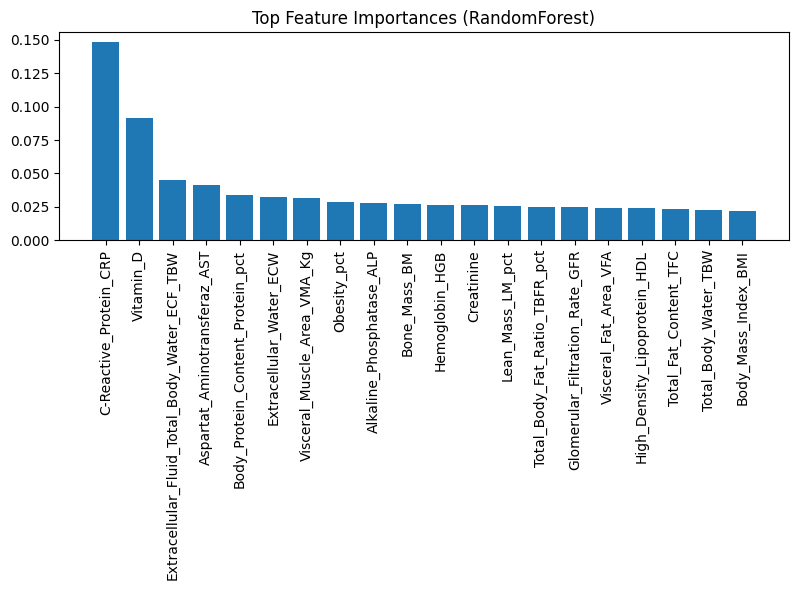

In [2]:
importances = final_clf.feature_importances_
order = np.argsort(importances)[::-1]
top_k = min(20, len(importances))

plt.figure(figsize=(8,6))
plt.bar(range(top_k), importances[order][:top_k])
plt.xticks(range(top_k), [feature_names[i] for i in order[:top_k]], rotation=90)
plt.title("Top Feature Importances (RandomForest)")
plt.tight_layout()
plt.show()

## Permutation importance (on test set)

In [3]:
r = permutation_importance(final_clf, X_test, y_test, n_repeats=20, random_state=42, scoring="roc_auc")

# Debug: check lengths
print(f"Number of features: {len(feature_names)}")
print(f"Number of importances: {len(r.importances_mean)}")

perm_imp = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": r.importances_mean,
    "importance_std": r.importances_std
}).sort_values("importance_mean", ascending=False)

perm_imp.head(40)

Number of features: 38
Number of importances: 38


,feature,importance_mean,importance_std
35,C-Reactive_Protein_CRP,0.098090,0.042666
37,Vitamin_D,0.040755,0.019775
13,Extracellular_Fluid_Total_Body_Water_ECF_TBW,0.020356,0.012676
11,Extracellular_Water_ECW,0.012413,0.009199
24,Hepatic_Fat_Accumulation_HFA,0.009462,0.005441
36,Hemoglobin_HGB,0.006858,0.005272
12,Intracellular_Water_ICW,0.006380,0.003613
25,Glucose,0.006120,0.002416
33,Creatinine,0.005425,0.004600
22,Visceral_Fat_Area_VFA,0.004818,0.006376


## Narrative Summary (Template)

**Background.** We trained multiple classifiers on 319 outpatients (June 2022–June 2023) with 38 clinical + bioimpedance + lab features; the target was *Gallstone Status* (Yes/No).

**Methods.** After cleaning column names, we label-encoded the target and applied standardization to features. We performed a stratified train/valid/test split (70/15/15). Baseline models (LogReg, Decision Tree, Random Forest) were compared on validation ROC–AUC and then tuned with cross-validated grid search (LogReg, RF, SVM). The best model was refit on train+valid and evaluated on the held-out test set.

**Results.** Report accuracy, precision, recall, F1, ROC–AUC on the test set. Include the confusion matrix and ROC curve. Highlight top contributing features (model importances and permutation importance).

**Conclusion.** Provide a short statement on expected clinical utility, strengths (non-imaging features, balanced classes, no missingness), and limitations (single-center cohort, small N, potential device/lab variability). Add next steps (external validation, calibration, decision thresholds, cost-sensitive evaluation).